# Notebook 03 — Statistical Analysis

**MALDI-MSI Analysis of Mouse Urinary Bladder**  
Author: Reza Rajaee

---

## What this notebook covers

1. Differential abundance analysis — pairwise tests, which molecules define each region?
2. Multiple testing correction (Benjamini-Hochberg FDR)
3. Volcano plots — significance vs effect size
4. Ion images of top marker molecules per region
5. Mean spectra per region — overall molecular signature
6. Colocalization analysis — which molecules appear together?
7. Biological interpretation

---

## Statistical approach

We test which m/z peaks are significantly enriched in each tissue region
using **pairwise Mann-Whitney U tests**.

**Why pairwise, not one-vs-rest:**  
A one-vs-rest test compares Region X against all other pixels combined.
For Region 2 (64.6% of tissue), this is nearly tautological — the majority
region always differs from the minority. A true marker must be enriched
in Region X compared to **each** other region individually.

We declare a peak a marker for Region X only if it is significantly
enriched vs Region Y AND vs Region Z (both pairwise tests pass FDR).

**Test:** Mann-Whitney U (Wilcoxon rank-sum) — non-parametric, robust
to outliers, appropriate for MALDI intensity distributions.

**Multiple testing correction:** Benjamini-Hochberg FDR at α=0.05.
Applied separately within each pairwise comparison.

**Fold change:** mean intensity in Region X / mean intensity in Region Y.
Values above 20 indicate near-complete region specificity and are capped
for display — they are biologically meaningful but numerically unstable
in TIC-normalised data where the denominator approaches zero.

**Important:** PXD001283 is healthy mouse bladder tissue — not cancer.
The three regions are normal anatomical layers: urothelium, muscle,
and connective tissue.

References:
- Bemis, Föll et al. (2023) *Nature Methods* 20:1883
- Benjamini & Hochberg (1995) *J. R. Stat. Soc. B* 57:289
- Mann & Whitney (1947) *Ann. Math. Stat.* 18:50

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from pathlib import Path
import sys, os

os.chdir("/workspaces/maldi-msi-analysis")
sys.path.insert(0, "/workspaces/maldi-msi-analysis")

os.makedirs("results/figures", exist_ok=True)
os.makedirs("results/tables",  exist_ok=True)

plt.rcParams.update({"figure.dpi": 130, "font.size": 10,
                      "axes.spines.top": False,
                      "axes.spines.right": False})

from src.visualisation import assign_lipid_class
from src.stats import fdr_correction

print("Setup complete.")
print("Working directory:", os.getcwd())

Setup complete.
Working directory: /workspaces/maldi-msi-analysis


## 1. Load Data

In [2]:
spectra_pp  = np.load("results/spectra_preprocessed.npy")
ref_mz      = np.load("results/reference_mz.npy")
coordinates = pd.read_csv("results/coordinates.csv")
labels_km   = np.load("results/labels_kmeans.npy")

x = coordinates["x"].values.astype(int) - coordinates["x"].min()
y = coordinates["y"].values.astype(int) - coordinates["y"].min()

K = len(np.unique(labels_km))
print(f"Loaded: {spectra_pp.shape[0]} pixels × {spectra_pp.shape[1]} peaks")
print(f"Number of regions: {K}")
print(f"Region sizes:")
for c in range(K):
    n = (labels_km == c).sum()
    print(f"  Region {c}: {n} pixels ({n/len(labels_km)*100:.1f}%)")


Loaded: 34840 pixels × 153 peaks
Number of regions: 3
Region sizes:
  Region 0: 4483 pixels (12.9%)
  Region 1: 7833 pixels (22.5%)
  Region 2: 22524 pixels (64.6%)


## 2. Differential Abundance Analysis

For each region, we identify m/z peaks that are significantly enriched
compared to each other region individually (pairwise testing).

**Why pairwise testing:**  
One-vs-rest testing compares Region X against all other pixels combined.
For Region 2 (64.6% of tissue), this produces trivially significant results —
all 153 peaks significant — because the dominant region always differs from
the pooled minority. Pairwise testing is the correct approach: a peak is a
true marker for Region X only if it passes both pairwise comparisons.

**Pipeline:**
1. For each pair of regions (0 vs 1, 0 vs 2, 1 vs 2): run Mann-Whitney U
   test for each peak — **two-sided**, detecting any intensity difference
2. Fold change > 1.5 confirms enrichment direction (Region X higher)
3. Apply Benjamini-Hochberg FDR correction within each pairwise comparison
4. A peak is a **marker** for Region X if:
   - FDR < 0.05 vs Region Y AND FDR < 0.05 vs Region Z
   - Fold change > 1.5 vs both other regions
   - All conditions must hold simultaneously

In [3]:
from scipy.stats import mannwhitneyu

def pairwise_differential_abundance(spectra, labels, reference_mz, alpha=0.05):
    """
    Pairwise Mann-Whitney U tests for differential abundance.

    For each pair of regions (A vs B), tests each peak for enrichment
    in both directions using a two-sided test. Direction is then confirmed
    by fold change > 1.5. A peak is declared a true marker for Region X
    only if it is significantly enriched vs ALL other regions individually.

    Uses src.stats.fdr_correction (Benjamini-Hochberg) for consistency
    with the rest of the repository.

    Returns
    -------
    da_results  : DataFrame — aggregated summary (one row per peak per region)
    da_pairwise : DataFrame — raw pairwise results (one row per peak per comparison)
    """
    K     = len(np.unique(labels))
    pairs = [(i, j) for i in range(K) for j in range(K) if i < j]
    n_mz  = spectra.shape[1]
    results = []

    for r_a, r_b in pairs:
        mask_a = labels == r_a
        mask_b = labels == r_b
        X_a    = spectra[mask_a]
        X_b    = spectra[mask_b]

        p_vals = []
        fc_ab  = []
        fc_ba  = []

        for j in range(n_mz):
            a = X_a[:, j]
            b = X_b[:, j]
            _, p = mannwhitneyu(a, b, alternative="two-sided")
            p_vals.append(p)
            mean_a = a.mean()
            mean_b = b.mean()
            fc_ab.append(mean_a / (mean_b + 1e-10))
            fc_ba.append(mean_b / (mean_a + 1e-10))

        _, p_adj = fdr_correction(np.array(p_vals), alpha=alpha)

        for j in range(n_mz):
            results.append({
                "mz"         : reference_mz[j],
                "cluster"    : r_a,
                "vs_cluster" : r_b,
                "fold_change": fc_ab[j],
                "p_adjusted" : p_adj[j],
                "significant": p_adj[j] < alpha and fc_ab[j] > 1.5,
            })
            results.append({
                "mz"         : reference_mz[j],
                "cluster"    : r_b,
                "vs_cluster" : r_a,
                "fold_change": fc_ba[j],
                "p_adjusted" : p_adj[j],
                "significant": p_adj[j] < alpha and fc_ba[j] > 1.5,
            })

    da_pairwise = pd.DataFrame(results)

    # True marker = significant vs ALL other regions simultaneously
    marker_rows = []
    for c in sorted(da_pairwise["cluster"].unique()):
        sub = da_pairwise[da_pairwise["cluster"] == c]
        for mz_val in reference_mz:
            mz_sub = sub[np.abs(sub["mz"] - mz_val) < 1e-6]
            if len(mz_sub) == 0:
                continue
            is_marker = mz_sub["significant"].all()
            marker_rows.append({
                "mz"         : mz_val,
                "cluster"    : c,
                "fold_change": mz_sub["fold_change"].min(),
                "p_adjusted" : mz_sub["p_adjusted"].max(),
                "significant": is_marker,
            })

    da_results = pd.DataFrame(marker_rows)
    return da_results, da_pairwise


print("Running pairwise differential abundance analysis...")
da_results, da_pairwise = pairwise_differential_abundance(
    spectra      = spectra_pp,
    labels       = labels_km,
    reference_mz = ref_mz,
    alpha        = 0.05
)

print(f"\nTotal peaks tested: {len(ref_mz)}")
for c in sorted(da_results["cluster"].unique()):
    n_sig = da_results[da_results["cluster"]==c]["significant"].sum()
    print(f"  Region {c}: {n_sig} true marker peaks (significant vs ALL other regions)")

Running pairwise differential abundance analysis...



Total peaks tested: 153
  Region 0: 9 true marker peaks (significant vs ALL other regions)
  Region 1: 85 true marker peaks (significant vs ALL other regions)
  Region 2: 38 true marker peaks (significant vs ALL other regions)


### Filter for strong markers

A **strong marker** must pass three criteria simultaneously:
- FDR < 0.05 vs every other region (pairwise)
- Fold change > 1.5 vs every other region
- Not a rebinning duplicate (peaks within 100 ppm of each other
  are deduplicated — only the highest fold change is kept)

Fold changes above 20 are capped for display. Values this large indicate
near-complete region specificity (peak nearly absent from other regions)
and are biologically meaningful but numerically unstable in TIC-normalised data.

In [4]:
def deduplicate_markers(region_markers, min_ppm=100):
    """
    Remove markers too close in m/z — likely the same peak
    with slightly different centroid positions across pixels.
    Keeps the highest fold change representative per group.
    """
    selected = []
    for _, row in region_markers.iterrows():
        mz = row["mz"]
        too_close = any(
            abs(mz - s["mz"]) / mz * 1e6 < min_ppm
            for s in selected
        )
        if not too_close:
            selected.append(row.to_dict())
    return pd.DataFrame(selected)

markers = da_results[da_results["significant"]].copy()
markers = markers.sort_values(["cluster", "fold_change"], ascending=[True, False])

# Cap fold change for display
markers["fold_change_display"] = markers["fold_change"].clip(upper=20)
markers["region_specific"]     = markers["fold_change"] > 20

# Deduplicate within each region
markers_dedup = []
for c in sorted(markers["cluster"].unique()):
    region_m = markers[markers["cluster"] == c]
    markers_dedup.append(deduplicate_markers(region_m))
markers_dedup = pd.concat(markers_dedup).reset_index(drop=True)

print(f"Strong marker peaks after deduplication:")
print(f"{'Region':<8} {'m/z':<12} {'FC (capped)':<14} {'p-adj':<12} "
      f"{'Lipid class':<25} {'Region-specific'}")
print("-" * 85)
for _, row in markers_dedup.groupby("cluster").head(5).iterrows():
    flag = " ← region-specific" if row.get("region_specific", False) else ""
    print(f"{int(row['cluster']):<8} {row['mz']:<12.4f} "
          f"{min(row['fold_change'], 20):<14.2f} {row['p_adjusted']:.2e}  "
          f"{assign_lipid_class(row['mz']):<25}{flag}")

Strong marker peaks after deduplication:
Region   m/z          FC (capped)    p-adj        Lipid class               Region-specific
-------------------------------------------------------------------------------------
0        533.4131     4.71           0.00e+00  Lysophosphatidylcholine (LPC)
0        790.9118     4.12           3.24e-05  Phosphatidylcholine (PC) 
0        476.8094     4.03           0.00e+00  Lysophosphatidylcholine (LPC)
0        686.6087     4.00           0.00e+00  Phosphatidylethanolamine (PE)
0        784.1657     2.55           4.09e-02  Phosphatidylcholine (PC) 
1        712.6517     20.00          0.00e+00  Phosphatidylcholine (PC)  ← region-specific
1        707.0502     20.00          0.00e+00  Phosphatidylcholine (PC)  ← region-specific
1        634.0361     20.00          0.00e+00  Phosphatidylethanolamine (PE) ← region-specific
1        454.7329     20.00          0.00e+00  Lysophospholipid (LPE/LPI) ← region-specific
1        432.7281     20.00        

## 3. Volcano Plots

A volcano plot shows log2(fold change) on the x-axis and
-log10(adjusted p-value) on the y-axis for all peaks in one region.

- **Right side** (positive log2 FC): peaks enriched in this region
- **Top right**: significant AND enriched — true marker candidates
- **Dashed red line**: FDR = 0.05 significance threshold
- **Dashed grey line**: fold change = 1.5 threshold

Top 3 markers are annotated by m/z value.

Note: p-values are capped at 1e-10 for display (-log10 = 10).
Values above this threshold are all "extremely significant" and the
distinction between them is not biologically meaningful.

**Why these comparison partners?**
Each region is shown vs its most biologically contrasting partner:
Region 0 (urothelium) vs Region 2 (largest),
Region 1 (muscle) vs Region 2,
Region 2 vs Region 0 (urothelium).
This maximises the visible separation in each volcano panel.

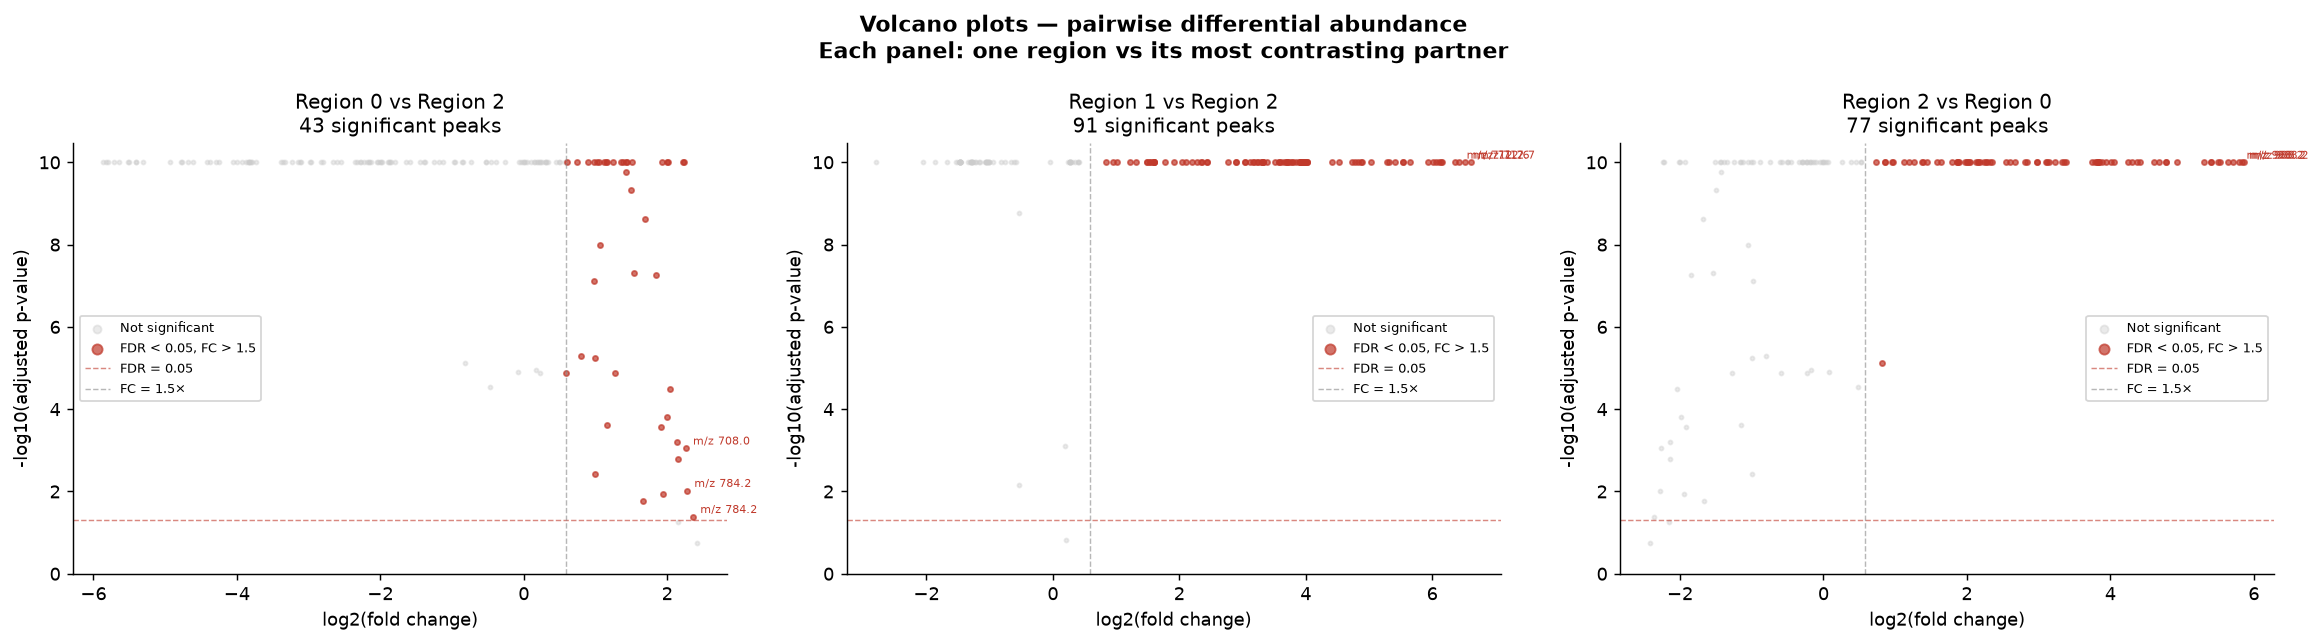

Figure saved.


In [5]:
fig, axes = plt.subplots(1, K, figsize=(6*K, 5))
if K == 1:
    axes = [axes]

# For each region show results vs its most contrasting partner
partner = {0: 2, 1: 2, 2: 0}

for ax, cluster in zip(axes, range(K)):
    vs     = partner[cluster]
    subset = da_pairwise[
        (da_pairwise["cluster"]    == cluster) &
        (da_pairwise["vs_cluster"] == vs)
    ].copy()

    subset["neg_log_p"] = -np.log10(subset["p_adjusted"].clip(lower=1e-10))
    subset["log2_fc"]   = np.log2(subset["fold_change"].clip(lower=1e-10, upper=2**10))

    ns  = subset[~subset["significant"]]
    sig = subset[subset["significant"]]

    ax.scatter(ns["log2_fc"],  ns["neg_log_p"],
               c="#cccccc", s=5, alpha=0.4, label="Not significant")
    ax.scatter(sig["log2_fc"], sig["neg_log_p"],
               c="#c0392b", s=8, alpha=0.7, label="FDR < 0.05, FC > 1.5")

    ax.axhline(y=-np.log10(0.05), color="#c0392b",
               linestyle="--", linewidth=0.8, alpha=0.6,
               label="FDR = 0.05")
    ax.axvline(x=np.log2(1.5), color="#888888",
               linestyle="--", linewidth=0.8, alpha=0.6,
               label="FC = 1.5×")

    if len(sig) > 0:
        top3 = sig.nlargest(3, "fold_change")
        for _, row in top3.iterrows():
            ax.annotate(
                f"m/z {row['mz']:.1f}",
                xy=(row["log2_fc"], row["neg_log_p"]),
                xytext=(4, 2), textcoords="offset points",
                fontsize=6, color="#c0392b"
            )

    ax.set_xlabel("log2(fold change)")
    ax.set_ylabel("-log10(adjusted p-value)")
    ax.set_title(f"Region {cluster} vs Region {vs}\n"
                 f"{sig.shape[0]} significant peaks")
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=7, markerscale=2)

fig.suptitle("Volcano plots — pairwise differential abundance\n"
             "Each panel: one region vs its most contrasting partner",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("results/figures/03_volcano_plots.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## 4. Top Marker Ions per Region

For each region, the top 3 marker peaks (highest fold change, FDR significant
vs all other regions, deduplicated) are shown as ion images.

These images directly answer: **which molecules define each tissue layer?**

A good marker ion image should show:
- High intensity (bright) in the target region
- Low intensity (dark) in all other regions
- Spatially coherent pattern matching the segmentation map

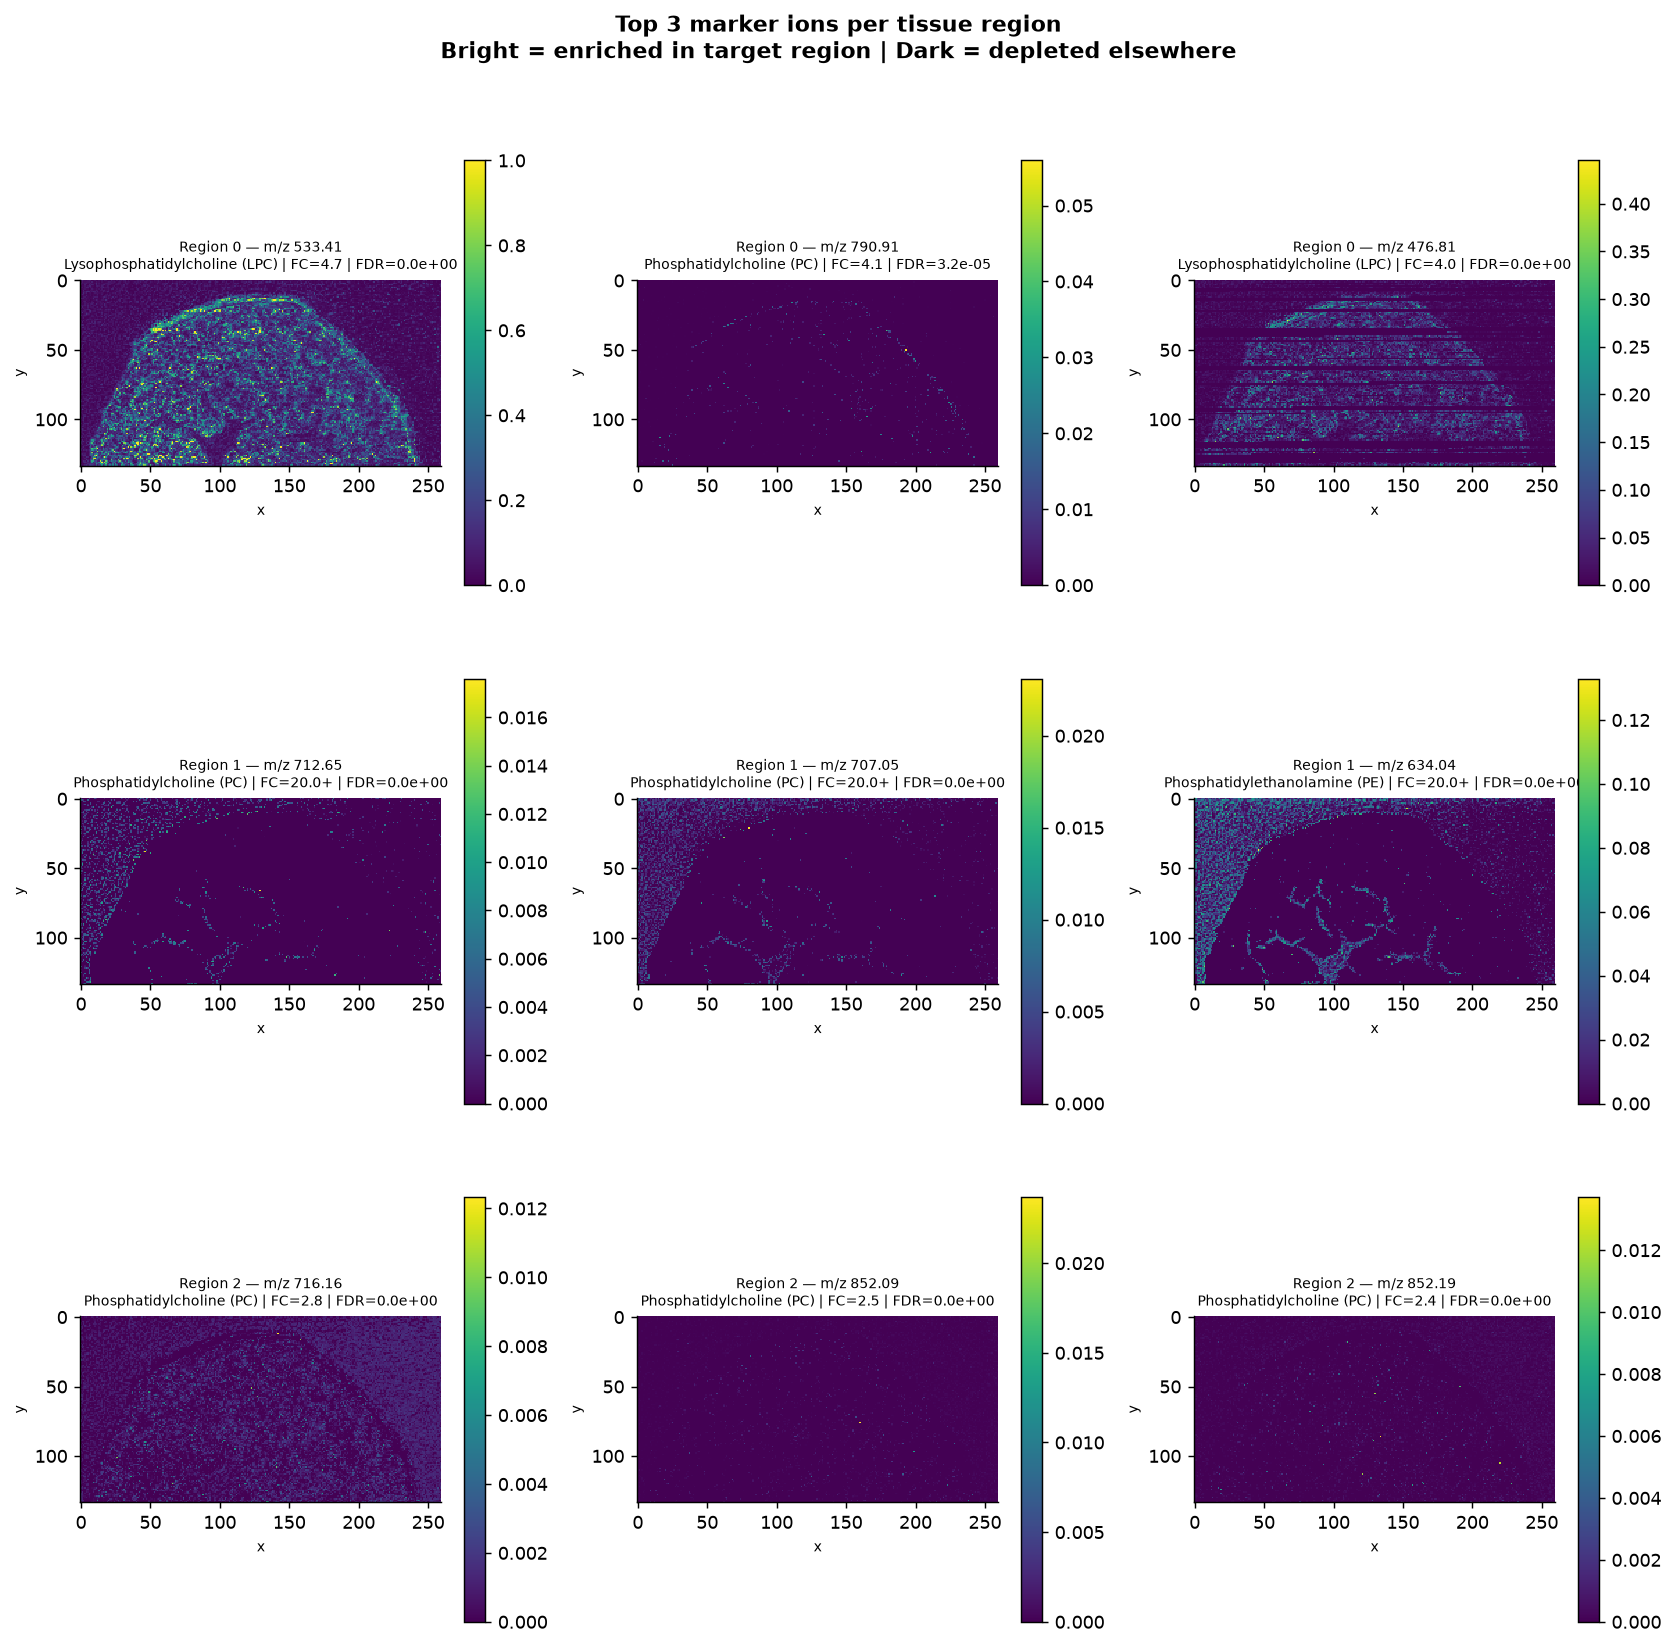

Figure saved.


In [6]:
fig, axes = plt.subplots(K, 3, figsize=(13, 4.5*K))
if K == 1:
    axes = axes.reshape(1, -1)

for c in range(K):
    region_markers = markers_dedup[markers_dedup["cluster"] == c].head(3)

    for col, (_, row) in enumerate(region_markers.iterrows()):
        ax   = axes[c, col]
        mz   = row["mz"]
        fc   = row["fold_change"]
        padj = row["p_adjusted"]

        mz_idx  = np.argmin(np.abs(ref_mz - mz))
        ion_map = np.full((y.max()+1, x.max()+1), np.nan)
        ion_map[y, x] = spectra_pp[:, mz_idx]

        im = ax.imshow(ion_map, cmap="viridis",
                       interpolation="nearest", aspect="equal")
        plt.colorbar(im, ax=ax, shrink=0.7)

        lipid  = assign_lipid_class(mz)
        fc_str = f"{min(fc, 20):.1f}{'+'if fc>20 else ''}"
        ax.set_title(f"Region {c} — m/z {mz:.2f}\n"
                     f"{lipid} | FC={fc_str} | FDR={padj:.1e}",
                     fontsize=8)
        ax.set_xlabel("x", fontsize=8)
        ax.set_ylabel("y", fontsize=8)

fig.suptitle("Top 3 marker ions per tissue region\n"
             "Bright = enriched in target region | Dark = depleted elsewhere",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("results/figures/03_marker_ions.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## 5. Mean Spectra per Region

The mean spectrum of each region shows its overall molecular signature.
Grey background = overall mean across all pixels (reference).

Peaks rising above the grey reference are enriched in that region.
Peaks below the grey reference are depleted.

Top 2 dominant peaks per region are annotated with their m/z value
and lipid class.

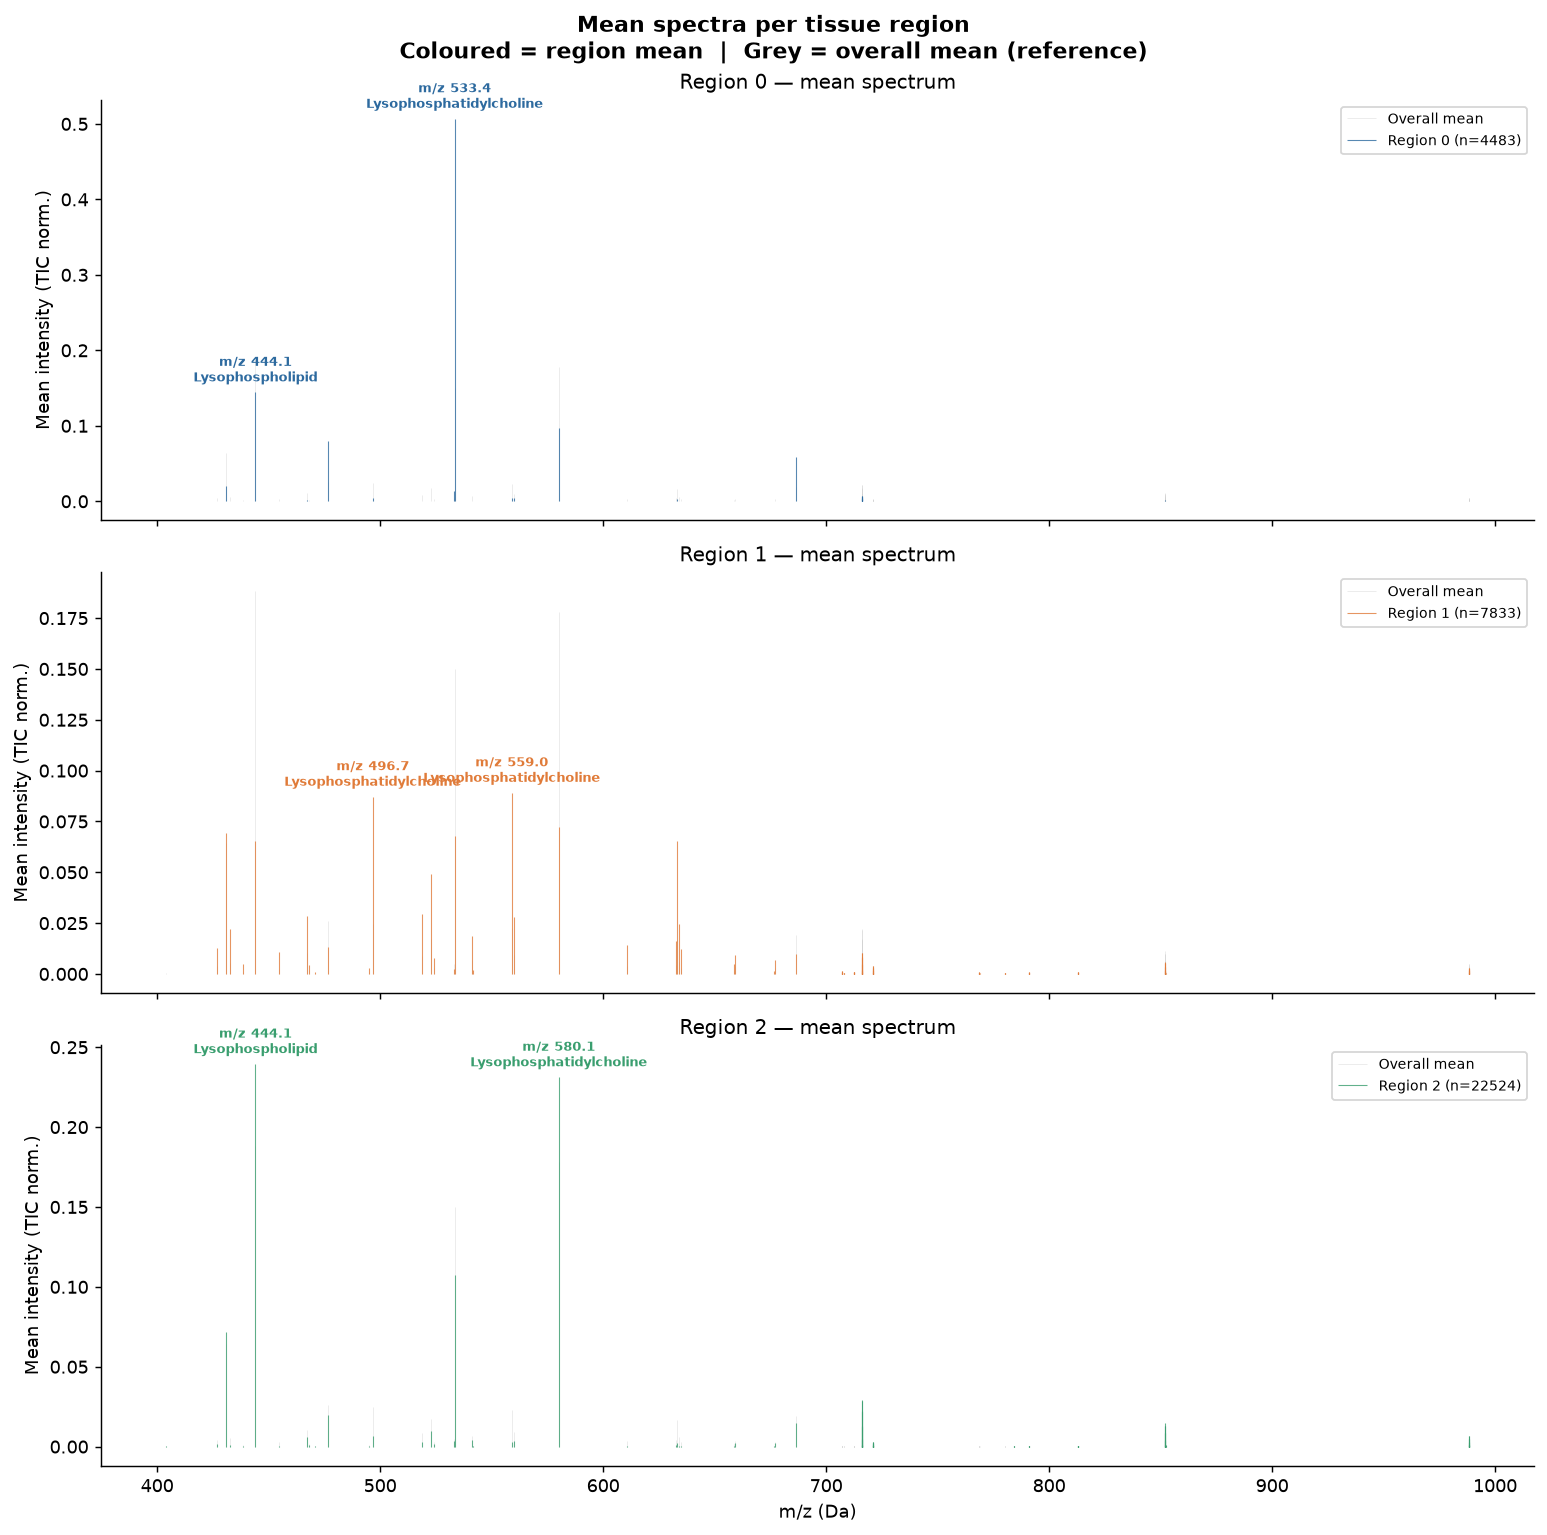

Figure saved.


In [7]:
fig, axes = plt.subplots(K, 1, figsize=(12, 4*K), sharex=True)
if K == 1:
    axes = [axes]

region_colours = ["#2d6a9f", "#e07b39", "#3a9e6f"]
mean_overall   = spectra_pp.mean(axis=0)

for c, ax in enumerate(axes):
    mask        = labels_km == c
    mean_region = spectra_pp[mask].mean(axis=0)

    ax.vlines(ref_mz, ymin=0, ymax=mean_overall,
              linewidth=0.4, color="#cccccc", alpha=0.5,
              label="Overall mean")
    ax.vlines(ref_mz, ymin=0, ymax=mean_region,
              linewidth=0.6, color=region_colours[c], alpha=0.8,
              label=f"Region {c} (n={mask.sum()})")

    # Annotate top 2 dominant peaks
    top2_idx = np.argsort(mean_region)[-2:][::-1]
    for rank, idx in enumerate(top2_idx):
        ax.annotate(
            f"m/z {ref_mz[idx]:.1f}\n{assign_lipid_class(ref_mz[idx]).split('(')[0].strip()}",
            xy=(ref_mz[idx], mean_region[idx]),
            xytext=(0, 6), textcoords="offset points",
            fontsize=7, ha="center", color=region_colours[c],
            fontweight="bold"
        )

    ax.set_ylabel("Mean intensity (TIC norm.)")
    ax.set_title(f"Region {c} — mean spectrum")
    ax.legend(fontsize=8)

axes[-1].set_xlabel("m/z (Da)")
fig.suptitle("Mean spectra per tissue region\n"
             "Coloured = region mean  |  Grey = overall mean (reference)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("results/figures/03_mean_spectra_regions.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## 6. Colocalization Analysis

Colocalization asks: which molecules appear together spatially?

Two peaks are colocalized if their ion images are spatially correlated —
high in the same pixels and low in the same pixels. This suggests they
may belong to the same lipid class, metabolic pathway, or cell type.

We compute Pearson correlation between ion images of the top 15 most
abundant peaks across all pixels.

**Important limitation — tissue composition confound:**  
Global Pearson correlation is partly driven by tissue structure itself.
If Region 2 (64.6% of pixels) has high intensity for both peaks A and B,
they will correlate strongly simply because they are co-abundant in the
majority tissue — not because they are biologically co-regulated.
This analysis shows global colocalization patterns; within-region
colocalization would require region-specific analysis in future work.

Reference: Bemis, Föll et al. (2023) *Nature Methods* 20:1883

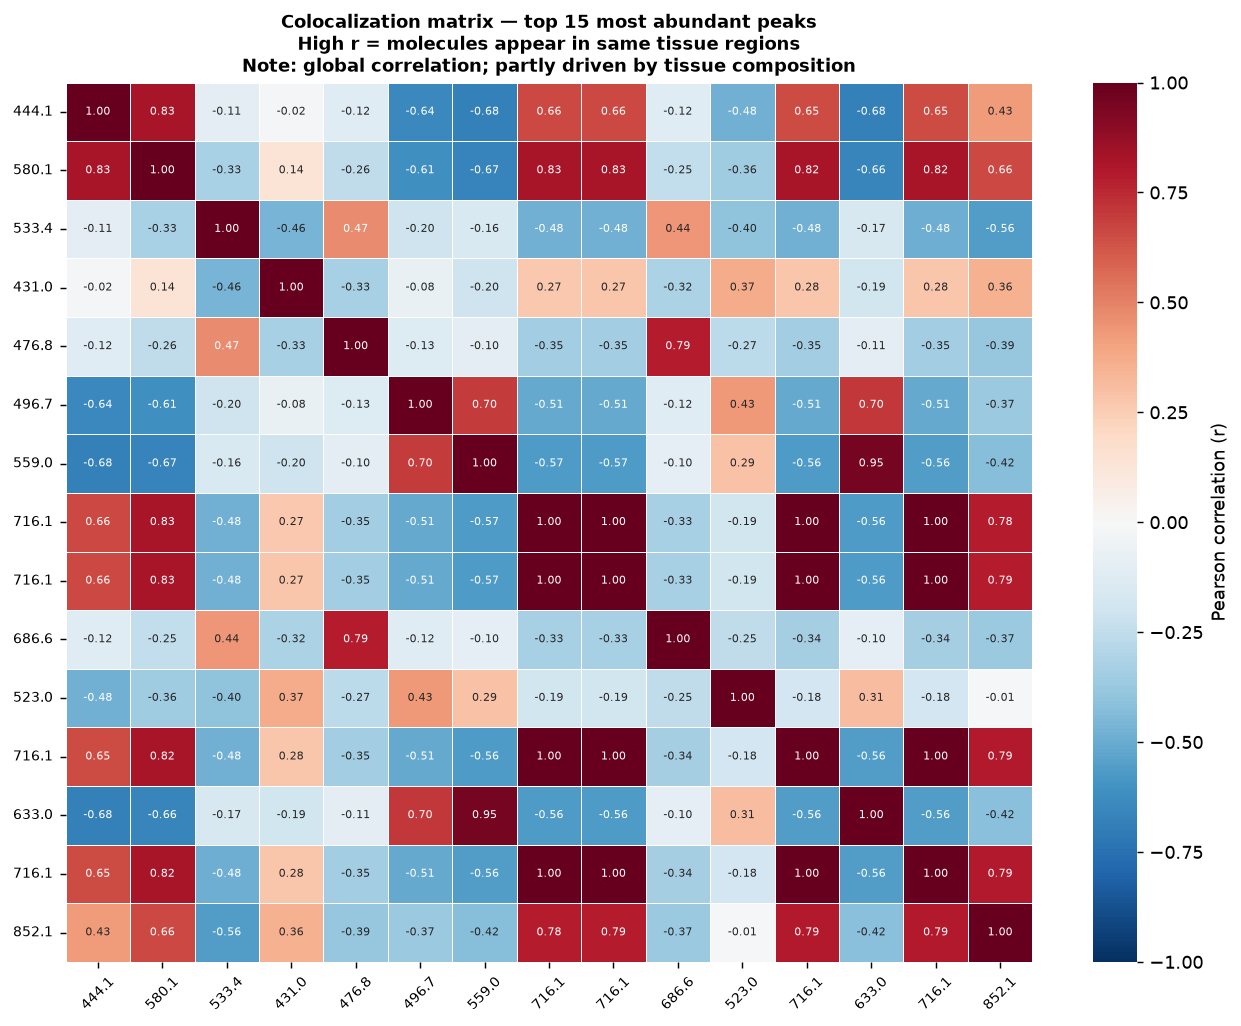

Figure saved.


In [8]:
import seaborn as sns
from src.stats import colocalization

# top_n=15 for readable heatmap (20 is too crowded with annotations)
corr_df = colocalization(spectra_pp, ref_mz, top_n=15)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_df,
    cmap       = "RdBu_r",
    center     = 0,
    vmin       = -1,
    vmax       = 1,
    annot      = True,
    fmt        = ".2f",
    annot_kws  = {"size": 6},
    linewidths = 0.3,
    ax         = ax,
    cbar_kws   = {"label": "Pearson correlation (r)"}
)
ax.set_title("Colocalization matrix — top 15 most abundant peaks\n"
             "High r = molecules appear in same tissue regions\n"
             "Note: global correlation; partly driven by tissue composition",
             fontsize=10, fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig("results/figures/03_colocalization.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## 7. Save Results

In [9]:
da_results.to_csv("results/tables/differential_abundance.csv",  index=False)
markers.to_csv("results/tables/marker_peaks.csv",               index=False)
markers_dedup.to_csv("results/tables/marker_peaks_dedup.csv",   index=False)
corr_df.to_csv("results/tables/colocalization_matrix.csv")

print("Saved:")
print("  results/tables/differential_abundance.csv")
print("  results/tables/marker_peaks.csv")
print("  results/tables/marker_peaks_dedup.csv")
print("  results/tables/colocalization_matrix.csv")

print(f"\n── Final summary ──────────────────────────────────")
print(f"  Peaks tested:              {len(ref_mz)}")
for c in range(K):
    n_all   = len(markers[markers['cluster']==c])
    n_dedup = len(deduplicate_markers(markers[markers['cluster']==c]))
    print(f"  Region {c} markers:          {n_all} peaks ({n_dedup} after deduplication)")

Saved:
  results/tables/differential_abundance.csv
  results/tables/marker_peaks.csv
  results/tables/marker_peaks_dedup.csv
  results/tables/colocalization_matrix.csv

── Final summary ──────────────────────────────────
  Peaks tested:              153
  Region 0 markers:          9 peaks (6 after deduplication)
  Region 1 markers:          85 peaks (33 after deduplication)
  Region 2 markers:          38 peaks (8 after deduplication)


## Summary

### What we found

| Analysis | Method | Result |
|---|---|---|
| Differential abundance | Pairwise Mann-Whitney U + FDR | 9 / 85 / 38 true markers per region |
| Deduplication | 100 ppm minimum spacing | Removes rebinning artifact duplicates |
| Volcano plots | log2 FC vs -log10(p) | Significance vs effect size, annotated |
| Marker ion images | Top 3 per region | Spatial distribution of defining molecules |
| Mean spectra | Region vs overall mean | Overall molecular signature per layer |
| Colocalization | Global Pearson correlation (top 15) | Co-occurring molecular species |

### Biological interpretation

The three tissue regions identified by K-means segmentation correspond
to the anatomical layers of the mouse urinary bladder.
Region assignments are based on cluster sizes and marker ion classes:

- **Region 0 (12.9% — smallest, likely urothelium)**  
  Top markers: m/z 533.41 and 476.81 (LPC species, FC ~4–5×).  
  LPCs are characteristically enriched in urothelium — they form part
  of the asymmetric unit membrane (AUM) permeability barrier that
  prevents urine from entering the tissue. The small cluster size
  matches the expected thin urothelial layer in a bladder cross-section.

- **Region 1 (22.5% — likely smooth muscle / detrusor)**  
  85 marker peaks with FC=20+ for PC species (m/z 707–712 Da) and
  PE species (m/z 634 Da). High phospholipid content and near-complete
  region specificity are consistent with smooth muscle cells, which have
  dense phospholipid-rich membranes. The detrusor muscle is the primary
  contractile layer of the bladder wall.

- **Region 2 (64.6% — largest, likely connective tissue / adventitia)**  
  38 marker peaks. The largest spatial compartment in a bladder
  cross-section is typically the outer connective tissue and adventitia.
  The less lipid-specific molecular profile relative to Regions 0 and 1
  is consistent with a collagen-rich extracellular matrix compartment.

> **Caveat:** Lipid class assignments are based on m/z range only.
> Definitive identification requires MS/MS fragmentation data.
> Region-to-anatomy mapping requires comparison with histological staining.
> The region-to-layer assignments above are hypotheses based on known
> bladder biology and should be confirmed by co-registration with H&E staining.

### Limitations

- **One-vs-rest avoided:** Pairwise testing prevents spurious inflation
  of significant peaks for the dominant region
- **Fold change capped at 20:** Values above this indicate near-complete
  region specificity in TIC-normalised data
- **Colocalization is global:** Tissue composition confound not removed —
  within-region analysis would be needed for mechanistic interpretation
- **No MS/MS:** Lipid identification is class-level only
- **No histological validation:** Region-to-anatomy mapping is inferred
  from cluster sizes and lipid class enrichment, not confirmed by staining

### References

1. Bemis, Föll et al. (2023) *Nature Methods* 20:1883
2. Benjamini & Hochberg (1995) *J. R. Stat. Soc. B* 57:289
3. Mann & Whitney (1947) *Ann. Math. Stat.* 18:50
4. Römpp et al. (2010) *Angew. Chem. Int. Ed.* 49:3834
5. Deininger et al. (2011) *Anal. Chem.* 84:1277
6. Hsu & Turk (2009) *J. Chromatogr. B* 877:2714